# Monte Carlo
In this notebook, we shall explore the Monte-Carlo approach.

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np

# Load data  
log_returns = pd.read_csv('../data/log_returns.csv', index_col=0, parse_dates=True)
weights = np.array([0.30, 0.25, 0.20, 0.15, 0.10])
tickers = ['AAPL', 'MSFT', 'JPM', 'GLD', 'TLT'] # Equities, bank, gold, bonds e.g Apple Inc. and Microsoft Corp.
portfolio_returns = log_returns.dot(weights)
np.random.seed(42) # For reproducibility

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def monte_carlo_var(log_returns, weights, portfolio_value=1_000_000, simulations=10_000, horizon=1, confidence_level=0.99):
    weights = np.array(weights)
    mean_returns = log_returns.mean().values
    cov_matrix = log_returns.cov().values

    # Cholesky decomposition for generating correlated random returns
    L = np.linalg.cholesky(cov_matrix)

    simulated_portfolio_returns = []

    for _ in range(simulations):
        # Generate correlated random shocks
        z = np.random.standard_normal(len(weights))
        correlated_shocks = L @ z # @ is the matrix multiplication operator in Python 3.5+

        # Simulate returns for each asset
        simulated_returns = mean_returns + correlated_shocks

        # Portfolio return
        portfolio_return = np.dot(weights, simulated_returns)
        simulated_portfolio_returns.append(portfolio_return)

    simulated_portfolio_returns = np.array(simulated_portfolio_returns)

    mc_var = -np.percentile(simulated_portfolio_returns, (1 - confidence_level) * 100)
    mc_cvar = -simulated_portfolio_returns[simulated_portfolio_returns < -mc_var].mean()

    return {'simulated_returns': simulated_portfolio_returns, 'VaR': mc_var * portfolio_value, 'CVaR': mc_cvar * portfolio_value}




Next, we extend this to multi-day horizons using Geometric Brownian Motion (GBM) paths.

In [4]:
def monte_carlo_paths(log_returns, weights, portfolio_value=1_000_000, simulations=1000, horizon=252):
    weights = np.array(weights)
    mean_returns = log_returns.mean().values
    cov_matrix = log_returns.cov().values

    # Cholesky decomposition for generating correlated random returns
    L = np.linalg.cholesky(cov_matrix)

    all_paths = []

    for _ in range(simulations):
        path = [portfolio_value]
        for t in range(horizon):
            z = np.random.standard_normal(len(weights))
            correlated_shocks = L @ z # @ is the matrix multiplication operator in Python 3.5+
            daily_returns = mean_returns + correlated_shocks
            portfolio_daily_return = np.dot(weights, daily_returns)
            path.append(path[-1] * (1 + portfolio_daily_return))

        all_paths.append(path)

    return np.arrayall_paths

The next code, is to clear the cache memory

In [ ]:
import importlib
import src.monte_carlo as mc_module
importlib.reload(mc_module)
from src.monte_carlo import monte_carlo_var, monte_carlo_paths, monte_carlo_var_garch, fit_garch

Now we run a code to calculate the Monte-Carlo VaR and CVaR

In [ ]:
# Run Monte Carlo VaR and CVaR calculation
np.random.seed(42)
mc_gbm = monte_carlo_var(log_returns, weights, portfolio_value=1_000_000, simulations=10_000, horizon=1, confidence_level=0.99)

print("--- GBM Monte Carlo VaR and CVaR results---")
print(f"Monte Carlo VaR (99% confidence level): ${mc_gbm['VaR']:.0f}")
print(f"Monte Carlo CVaR (99% confidence level): ${mc_gbm['CVaR']:.0f}")


--- GBM Monte Carlo VaR and CVaR results---
Monte Carlo VaR (99% confidence level): $26219
Monte Carlo CVaR (99% confidence level): $30377


Next, we make the visualization of the Monte-Carlo paths.

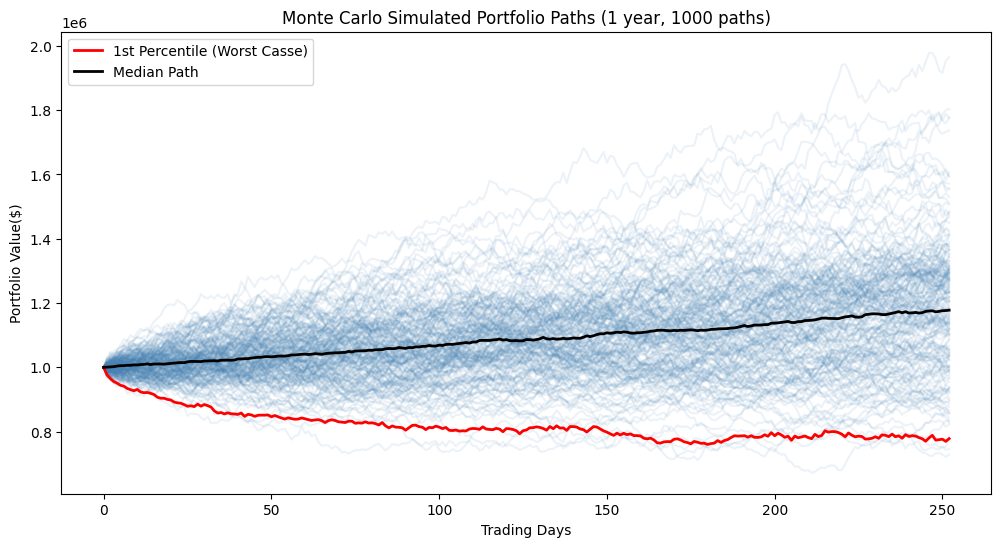

In [7]:
paths = monte_carlo_paths(log_returns, weights)

plt.figure(figsize=(12, 6))
plt.plot(paths[:200].T, alpha=0.1, color='steelblue')  # Plot the first 200 paths for clarity
plt.plot(np.percentile(paths, 1, axis=0), color='red', linewidth=2, label='1st Percentile (Worst Casse)')
plt.plot(np.percentile(paths, 50, axis=0), color='black', linewidth=2, label='Median Path')
plt.title('Monte Carlo Simulated Portfolio Paths (1 year, 1000 paths)')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value($)')
plt.legend()
plt.savefig('../outputs/monte_carlo_paths.png', dpi=150)  # Save the plot to a file.
plt.show()


## GARCH
This replaces the constant volatility in the GBM with a GARCH-modeled volatility.

In [8]:
from arch import arch_model

def fit_garch(returns_series):
    model = arch_model(returns_series * 100, vol='Garch', p=1, q=1)
    result = model.fit(disp='off')
    forecasts = result.forecast(horizon=1)
    garch_volatility = np.sqrt(forecasts.variance.values[-1, 0]) / 100
    return garch_volatility, result

# Compare GARCH volatility with historical volatility for each asset
for ticker in tickers:
    hist_vol = log_returns[ticker].std()
    garch_volatility, _ = fit_garch(log_returns[ticker])
    print(f"{ticker}: Historical Volatility = {hist_vol:.4f}, GARCH Volatility = {garch_volatility:.4f}")

AAPL: Historical Volatility = 0.0203, GARCH Volatility = 0.0112
MSFT: Historical Volatility = 0.0192, GARCH Volatility = 0.0100
JPM: Historical Volatility = 0.0201, GARCH Volatility = 0.0099
GLD: Historical Volatility = 0.0094, GARCH Volatility = 0.0081
TLT: Historical Volatility = 0.0111, GARCH Volatility = 0.0109


Next, we run the Monte Carlo using the GARCH(1,1) volatility calculations.

In [9]:
def monte_carlo_var_garch(log_returns, weights, portfolio_value=1_000_000, simulations=10_000, confidence_level=0.99):

    """
    Monte Carlo VaR calculation using GARCH(1,1) volatility forecasts.
    """
    from arch import arch_model

    weights = np.array(weights)
    mean_returns = log_returns.mean().values

    # Next we use the fit GARCH(1,1) models to each asset  
    garch_volatility = np.array([fit_garch(log_returns[col])[0] for col in log_returns.columns]) # Get the GARCH volatility forecasts for each asset

    corr_matrix = log_returns.corr().values # Get the correlation matrix of returns
    garch_cov_matrix = np.outer(garch_volatility, garch_volatility) * corr_matrix # Construct the GARCH covariance matrix
    L = np.linalg.cholesky(garch_cov_matrix) # Cholesky decomposition for generating correlated random returns

    simulated_portfolio_returns = [] 
    for _ in range(simulations):
        z = np.random.standard_normal(len(weights)) # Generate correlated random shocks
        correlated_shocks = L @ z # @ is the matrix multiplication operator
        simulated_returns = mean_returns + correlated_shocks # Simulate returns for each asset
        portfolio_return = np.dot(weights, simulated_returns) # Portfolio return
        simulated_portfolio_returns.append(portfolio_return)

    simulated_portfolio_returns = np.array(simulated_portfolio_returns)
    mc_var = -np.percentile(simulated_portfolio_returns, (1 - confidence_level) * 100)
    mc_cvar = -simulated_portfolio_returns[simulated_portfolio_returns < -mc_var].mean()

    return {'simulated_returns': simulated_portfolio_returns, 'VaR': mc_var * portfolio_value, 'CVaR': mc_cvar * portfolio_value, 'garch_volatility': dict(zip(log_returns.columns, garch_volatility))}


In [13]:
np.random.seed(42)
mc_garch = monte_carlo_var_garch(log_returns, weights, portfolio_value=1_000_000, simulations=10_000, confidence_level=0.99)

print(f"Monte Carlo GBM VaR:   ${mc_gbm['VaR']:,.0f}")
print(f"GARCH Monte Carlo VaR: ${mc_garch['VaR']:,.0f}")

Monte Carlo GBM VaR:   $26,219
GARCH Monte Carlo VaR: $14,001
